<a href="https://colab.research.google.com/github/valentinaslisser/mlandmlops/blob/main/Discrete-Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

# Probability Theory for Discrete Outcomes

This is a very brief review of terminology, notation and results from basic probability theory.

## Sample space

When studying random experiments, the *sample space* is the set of outcomes potentially observable. We normally denote it by some capital Greek letter. For example, $\Omega$. In a coin flip, we may observe it land heads up or tails up, so the sample space of a coin flip is $\Omega = \{\text{H}, \text{T} \}$ (using H to mean heads and T to mean tails). The sample space of the experiment 'flip two coins' is $\Omega = \{ \text{HH}, \text{HT}, \text{TH}, \text{TT}\}$.

## Event

An event groups outcomes of a sample space, which makes an event itself a set. We say the event 'occurred' if any of its outcomes is observed. This is a convenient way to talk about properties of outcomes of random experiments. For example, in a certain game of chance, when I flip two coins, perhaps all I really care about is the number of 'heads'. Then we have events like

1. drawing no heads
2. drawing 1 heads
3. drawing 2 heads

These can be described as sets of outcomes as follows:

1. $\{TT\}$
2. $\{\text{HT}, \text{TH}\}$
3. $\{\text{HH}\}$

The space of all possible events is called the **event space**. There are different possibilities for event spaces, but normally we just assume all possible subsets of the sample space are possible events. All possible sets of a countable set is what we call the *powerset* of the set. The event space which is the powerset of the sample space is denoted $\mathbb P(\Omega)$ or also $2^\Omega$.

## Probability measure

A probability measure maps each event in the event space to a real number which we call a \textbf{probability}.  Probability measures are often denoted by $\mathbb P$ or $\Pr$.

For a probability measure, it must hold:

1. $\mathbb P(A) \ge 0$ for all $A \in \mathcal A$: the smallest probability value attainable by any event is 0;
2. $\mathbb P \left( \bigcup_{i=1}^n A_i \right) = \sum_{i=1}^n \mathbb P(A_i)$ for a countable collection $\{A_1, \ldots, A_n\} \subseteq \mathcal A$ of pairwise disjoint events: the total probability assigned to $n$ pairwise disjoint events is the sum of the probability values assigned to each of the $n$ events;
3. $\mathbb P(\Omega) = 1$: the event which is the set of all possible outcomes is assigned a total probability value of 1.


These properties also implie that

4. $\mathbb P(\emptyset) = 0$: the empty event has probability 0, that is, if we observed a random experiment something must have happened;
5. $\mathbb P(A \cup B) = \mathbb P(A) + \mathbb P(B) - \mathbb P(A \cap B)$ for events $A, B \in \mathcal A$: is a generalisation of property (2) which does not require disjoint events;
6. $\mathbb P(\Omega \setminus A) = 1 - \mathbb P(A)$ for an event $A \in \mathcal A$: the probability of the complement of an event $A$ in $\Omega$ (denoted $\Omega \setminus A$) is the 1 minus the probability of $A$; this result is known as the *complement rule*.

From now on, there will be many layers of abstractions and a lot of notation. Make an effort to keep track. And recall, the argument that the probability measure accepts is always a set of outcomes (i.e., an event).

There are many ways to specify probability measures, this is not really a concern of probability theory. Probability theory only tells us the *formal properties* of probabilities measures. We have the freedom to design them as we like as long as the result complies with these formal properties. Statistics will help us specify some probability measures with the help of observed data. Machine learning techniques will also help us specify some probability measures, in particular, for very complex event spaces.

For the two-coins example, we might specify the following probability measure:

\begin{equation}
\Pr(A) = \begin{cases}
0.2 & \text{if }A=\{TT\} \\
0.2 & \text{if }A=\{HH\}\\
0.6 & \text{if }A=\{\text{HT}, \text{TH}\}\\
0   & \text{otherwise}
\end{cases}
\end{equation}


You can verify that this function complies with all formal properties of probability measures and is, therefore, a probability measure.

Another way to specify a valid probability measure for this is to use another measure known as the *cardinality measure*. This can be a good model of coin flips under certain idealisations. For example, assume the coins are fair, independent, and the experimenter does not interfere with the results. Then the function

\begin{equation}
\Pr(A) = \frac{|A|}{|\Omega|}
\end{equation}

where $|A|$ is the number of elements in the set (the 'size' or 'cardinality' of the set) prescribes a valid probability measure. In this case, it would be:

\begin{equation}
\Pr(A) = \begin{cases}
0.25 & \text{if }A=\{TT\} \\
0.25 & \text{if }A=\{HH\}\\
0.5 & \text{if }A=\{\text{HT}, \text{TH}\}\\
0   & \text{otherwise}
\end{cases}
\end{equation}

You can verify it for yourself that this is a valid probability measure.

**Remark:** There's nothing objectively right or wrong about any of these measures, the first could be a decent model of the experiment depending on the circumstances. Similarly, the second could be a very bad approximation of reality (for example, if the coins aren't fair, experimenter isn't honest, etc.).

## Random variable

A random variable is an abstraction that allows us to give convenient mathematical treatment to the most diverse types of random experiments (involving the most diverse types of samples spaces).
Formally, a *real random variable* is a function that maps elements from a sample space $\Omega$ to (a subset of) the real line $\mathbb R$, known as the random variable's *range*.

For example, $X: \Omega \to \mathcal X$, with $\mathcal X \subseteq \mathbb R$ is a random variable whose domain (or sample space) is $\Omega$ and whose range is $\mathcal X$. By mapping outcomes to the real line we give outcomes a numerical treatment, which will be *very* convenient when designing tools to specify probability measures efficiently and in a compact manner.

For the 'heads in two coin flips', we could have a random variable:

\begin{equation}
X(\omega) = \begin{cases}
0 & \text{if }\omega=\text{TT} \\
1 & \text{if }\omega=\text{HT} \\
1 & \text{if }\omega=\text{TH}\\
2 & \text{if }\omega=\text{HH}
\end{cases}
\end{equation}

Here the range of $X$ is $\{0, 1, 2\} \subset \mathbb R$.

If we ever need to work out the specific event (in the event space) associated with an outcome $x$ of a random variable, we can use a shortcut notation: $X=x$, which is pronounced "$X$ takes on the value $x$". This notation evaluates to $\{\omega \in \Omega: X(\omega) = x\}$. That is, the set of all outcomes in the sample space $\Omega$ which the random variable $X$ maps to the outcome $x$ in its range.  For example, using the random variable above, $X=1$ evaluates to the event $\{\text{HT}, \text{TH}\}$.

**Remark:** it might look like the notation $X=x$ is a waste of symbols, and that we might as well simply replace it by $x$. That is not true though. Written alone, some $x$ from $\mathcal X$ is just a real value. Written alone, $X$ is a random variable (no specific value). Written together, $X=x$ we recover a set of outcomes in the sample space, or, more precisely, the specific event that corresponds to $X$ taking on the outcome $x$ in its range.

## Probability Distribution

A probability distribution $P_X$ is essentially a probability measure, but used specifically with random variables. That is why we use the subscript $_X$ in $P_X$.

If $X$ is a random variable with range $\mathcal X$ and distribution $P_X$, then $P_X(X=x)$ is the probability that $X$ takes on the value $x \in \mathcal X$.

Remarks:
* $X$ is not any one particular value of the random outcome, $X$ is at best described by its probability distribution;
* $x \in \mathcal X$ is an outcome in the range of the random variable $X$, this means that $x$ is a value that $X$ may take on (if you were to observe a realisation of the random phenomenon or experiment that $X$ is meant to model);
* $X=x$ is the notation we use to say that of all possible events that can happen, we concentrate only on the event that captures the outcomes of a random experiment that are consistent with $x$.
* it's common to drop the subscript $P_X(X=x)$, as in $P(X=x)$, while this is reasonably clear with a single variable, it gets less clear when we have multiple random variables (thus we recommend not to drop it);
* it's common to find notation such as $P(x)$, this is a big abuse of notation as the probability distribution *does not take real values as arguments*, rather, it needs events, that's why we write $P(X=x)$; sometimes you find $P_X(x)$, this is a bit better in that we can see the rv $X$ in the subscript and we may then imagine that $P_X(X=x)$ was meant, while $P(x)$ does not even tell you which rv to use;
* in this course we will often use $P_X(x)$ and make the inference that we mean $P_X(X=x)$ in our minds, that's because at one point we will have many random variables and the more precise notation $P_X(X=x)$ gets rather cluttered;
* finally, later we will learn about another important device, the probability mass function (pmf), which is a function of outcomes in the *range* of rv, that device is often denoted $p(x)$ or $f(x)$, or various other names (as we shall see), and that's why we better use notation for distributions carefully.


The two cells below illustrate the difference between a standard variable and a random variable. A standard variable gets assigned a value and never changes, unless we reassign that value.

In [2]:
v = 1
print([v for _ in range(10)])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


A random variable gets assigned a distribution of values. Each time we observe a realisation of the random variable, we in effect observe the result of a random phenomenon/experiment, which can be any one of the values that are in the range of our random variable (in the example below this can be 0 or 1). The type of distribution we choose and its parameters (we will learn more about that in a moment) determine the frequency with which we expect to see the possible outcomes.

In [3]:
observe_X = lambda : np.random.binomial(2, 0.5)
print([observe_X() for _ in range(10)])

[0, 1, 2, 2, 2, 1, 0, 1, 2, 1]


For any probability distribution, $\forall x \in \mathcal X$ it holds that  $0 \le P_X(X=x) \le 1$ and $\sum_{x \in \mathcal X} P_X(X=x) = 1$.

The notation $\forall x \in \mathcal X$ is pronounced "for all $x$ in the range of the random variable $X$".

The set $\mathrm{supp}(P_X)$ is the *support* of the distribution, that is, the subset of $\mathcal X$ for which $P_X(X=x)>0$.

An example we just used above is the Binomial distribution (you will learn more about it later), which captures the number of times we obtain in a number of random repetitions of an experiment with binary outcomes $0$ or $1$. This distribution is controlled by two parameters, the number of repetitions, and the probability of obtaining $1$ whenever we draw an outcome (this probability is kept fixed throughout all repetitions). The support of the random variable is the set of integers from $0$ to the total number of repetitions. So, if we flip a coin 3 times, the support of the Binomial distribution is $\{0, 1, 2, 3\}$, any other value is assigned probability 0. Later you will see the complete Binomial law, including the probability mass function that specifies the probabilities values of the different outcomes in the support.

## Cumulative distribution function

For a random variable $X$ with distribution $P_X$, the cumulative distribution function (cdf) is the function $F_X(a) = \sum_{x \le a} P_X(X=x)$.
Because probability values are never negative, the cdf is increasing and monotone.

The cdf plays an important role in sampling algorithms. In particular, if we draw $X$ from $P_X$ and evaluate the cdf, the distribution of the result is uniform over the interval $[0, 1]$. That is, $F_X(X) \sim \mathcal U(0, 1)$. Conversely, if $U$ is uniformly distributed over $[0,1]$, denoted $U\sim \mathcal U(0, 1)$, transforming $U$ through the inverse cdf $F^{-1}_X$, also known as *quantile function*, gives us a random variable $X$ with distribution $P_X$.

## Probability mass function

We often specify a probability distribution via a parametric function that relates the mass of an outcome to the outcome itself and a set of numerical parameters. The probability mass function (pmf) is a useful device to specify probability distributions through general mathematical laws (functions), rather than one probability value at a time. We normally name the pmf for convenience.

For example, $f(x; \theta) = \theta^x(1-\theta)^{1-x}$ is the pmf of a binary random variable that takes the value 1 with probability $\theta$, and the value 0 with probability $1-\theta$. The probability distribution $P_X$ such that $P_X(X=x)=f(x; \theta)$ also goes by the name of Bernoulli distribution.

Standard probability distributions are usually "named", which helps us remember the pmfs that prescribe them. We will see some examples later.

**Expected value**

The expected value (or mean) of a random variable is denoted $\mathbb E[X]$ and defined as $\mathbb E[X] = \sum_{x \in \mathrm{supp}(p_X)} x P_X(X=x)$.

**Variance**

The variance of a random variable is denoted $\mathrm{Var}(X)$ and defined as $\mathbb E[(X - \mathbb E[X])^2] = \mathbb E[X^2] - \mathbb E[X]^2$.

**Mode**

The modes of the distribution $P_X$ of the random variable $X$ are the values $x \in \mathcal X$ for which $P_X(X=x)$ is maximum.



# Standard Probability Distributions

## Bernoulli

The [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution) is the discrete probability distribution of a random variable which takes the value 1 with probability $p$ and the value 0 with probability $1-p$.

**Notation** If $X \sim \mathrm{Bernoulli}(p)$, then $P_X(X=x)$ is given by the Bernoulli pmf:
\begin{equation}
  \mathrm{Bernoulli}(x|p) = \begin{cases}
  p & x=1\\
  1-p & x=0\\
  0 & \text{otherwise}
  \end{cases}
\end{equation}  

**Properties**

* Support: $\{0, 1\}$
* Mean: $\mathbb E[X] = p$
* Variance: $\mathrm{var}(X)= \mathbb E[X^2] - \mathbb E[X]^2 =p(1-p)$
* Mode(s): $1$ if $p > 0.5$, $0$ if $p < 0.5$, $\{0, 1\}$ if $p=0.5$

Bernoulli pmf and cdf using scipy:

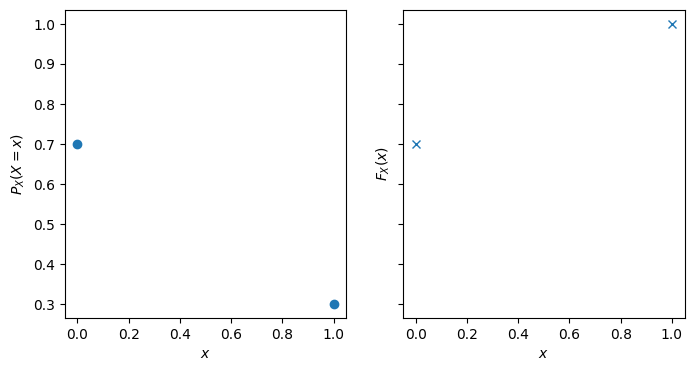

In [4]:
bern = st.bernoulli(0.3)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot([0, 1], bern.pmf([0, 1]), 'o')
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot([0, 1], bern.cdf([0, 1]), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

Drawing samples from Bernoulli using scipy:

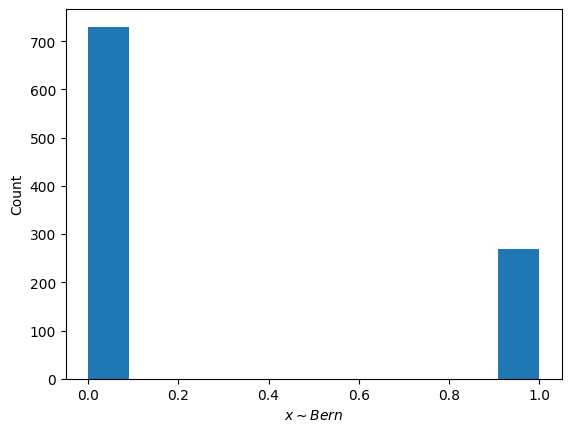

In [5]:
_ = plt.hist(bern.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$x \sim Bern$')
_ = plt.ylabel('Count')

## Categorical

The [Categorical distribution](https://en.wikipedia.org/wiki/Categorical_distribution) is the discrete probability distribution of a random variable that can take on one of $K$ possible categories, with the probability of each category separately specified.

**Notation** If $X \sim \mathrm{Categorical}(\pi_1, \ldots, \pi_K)$, then $P_X(X=x)$ is given by the Categorical pmf:
\begin{equation}
  \mathrm{Categorical}(x|\pi_{1}, \ldots, \pi_K) = \begin{cases}
  \pi_x & x \in \{1, \ldots, K\} \\  
  0 & \text{otherwise}
  \end{cases}
\end{equation}  
where $\pi_k \ge 0$ and $\sum_{k=1}^K \pi_k = 1$.
Other common notations: $X \sim \mathrm{Categorical}(\pi_{1:K})$, $X \sim \mathrm{Categorical}(\pi_1^K)$, and $X \sim \mathrm{Categorical}(\boldsymbol\pi)$ with $\boldsymbol\pi \in \Delta_{K-1}$.

The set $\Delta_{K-1} \subset \mathbb R^K$ is called the *probability simplex*, it is the set of $K$-dimensional vectors whose coordinates are positive and sum to 1.

**Properties**

* Support: $\{1, \ldots, K\}$
* Mean: undefined (Categorical outcomes are normally not interpreted as ordinal values)
* Variance: undefined (Categorical outcomes are normally not interpreted as ordinal values)
* Mode(s): $\{k: \pi_k = \max(\pi_1, \ldots, \pi_K)\} \subseteq \{1, \ldots, K\}$

We will make our own Categorical object imitating the scipy API:

In [ ]:
class Categorical:

    def __init__(self, probs):
        self._probs = np.array(probs)
        assert self._probs.size > 1, "We need 2 or more classes"
        assert self._probs.shape == (self._probs.size,), "probs must be a vector"
        assert np.all(self._probs >= 0), "The coordinates of the Categorical parameter must be positve"
        assert self._probs.sum() == 1, "The coordinates of the Categorical parameter must add to 1"

    def rvs(self, size=None):
        """Use this to draw 1 or more samples from the distribution"""
        # we shift by one because random.choice returns 0-based outcomes
        return np.random.choice(len(self._probs), p=self._probs, size=size) + 1

    def pmf(self, x):
        """Use this to assess the probability mass of the elements of a data vector"""
        x = np.array(x, dtype=int) - 1 # convert to 0-based
        return self._probs[x]

    def logpmf(self, x):
        """Use this to assess the logarithm of the probability mass of the elements of a data vector"""
        x = np.array(x, dtype=int) - 1 # covert to 0-based
        return np.log(self._probs[x])

    def cdf(self, x):
        if type(x) is int:
            return self._probs[:x].sum()
        else:
            x = np.array(x, dtype=int) - 1. # convert to 0-based
            # flags
            b = x[:, None] >= np.arange(self._probs.size)[None, :]
        # cdf
        return (b * self._probs).sum(-1)

In [ ]:
cat = Categorical([0.2, 0.1, 0.3, 0.4])
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot([1, 2, 3, 4], cat.pmf([1, 2, 3, 4]), 'o')
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot([1, 2, 3, 4], cat.cdf([1, 2, 3, 4]), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(cat.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$X \sim Cat$')
_ = plt.ylabel('Count')

## Binomial

The [Binomial distribution](https://en.m.wikipedia.org/wiki/Binomial_distribution) with parameters $n$ and $p$ is the discrete probability distribution of the number of successes in a sequence of $n$ independent experiments, each asking a yes–no question, and each with its own Boolean-valued outcome: success (with probability $p$) or failure (with probability $1 − p$).

**Notation** If $X \sim \mathrm{Binomial}(n, p)$, then $P_X(X=x)$ is given by the Binomial pmf:
\begin{equation}
  \mathrm{Binomial}(x|n, p) = \begin{cases}
  \binom{n}{x} p^x(1-p)^{n-x}& x \in \{0, \ldots, n\} \\  
  0 & \text{otherwise}
  \end{cases}
\end{equation}  
 where $n > 0$, $0 \le p \le 1$, and $\binom{n}{x} = \frac{n!}{x!(n-x)!}$, pronounced $n$-choose-$k$, is the binomial coefficient.

**Properties**

* Support: $\{0, \ldots, n\}$
* Mean: $\mathbb E[X] = np$
* Variance: $\mathrm{var}(X)= \mathbb E[X^2] - \mathbb E[X]^2=np(1-p)$
* Mode(s): $\lfloor (n+1)p \rfloor$ or $\lceil (n+1)p\rceil -1 $



In [ ]:
binom = st.binom(10, 0.3)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot(np.arange(11), binom.pmf(np.arange(11)), 'o')
_ = ax[0].set_xlim((-1, 11))
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot(np.arange(11), binom.cdf(np.arange(11)), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(binom.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$x \sim Binomial$')
_ = plt.ylabel('Count')

## Geometric

The [Geometric distribution](https://en.wikipedia.org/wiki/Geometric_distribution) is either one of two discrete probability distributions:

* The probability distribution of the number $X$ of Bernoulli trials needed to get one success, supported on the set $\{1, 2, \ldots\}$. In this case $P_X(X=x)$ is given by the pmf:
\begin{equation}
  \mathrm{Geometric}_1(x|p) = \begin{cases}
  p(1-p)^{x-1} & x \in \{1,2, \ldots\} \\  
  0 & \text{otherwise}
  \end{cases}
\end{equation}  
with $p > 0$.

  * Support: $\{1, 2, \ldots \}$
  * Mean: $\frac{1}{p}$
  * Variance: $\frac{1-p}{p^2}$
  * Mode: 1

* The probability distribution of the number $Y = X - 1$ of failures before the first success, supported on the set $\{0, 1, \ldots\}$. In this case $P_Y(Y=y)$ is given by the pmf
\begin{equation}
  \mathrm{Geometric}_0(y|p = \begin{cases}
  p(1-p)^{y} & x \in \{0, 1, \ldots\} \\  
  0 & \text{otherwise}
  \end{cases}
\end{equation}
with $p > 0$.

  * Support: $\{0, 1, \ldots \}$
  * Mean: $\frac{1-p}{p}$
  * Variance: $\frac{1-p}{p^2}$
  * Mode: 0

Scipy's default Geometric is Geometric1:

In [ ]:
geom1 = st.geom(0.6)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot(np.arange(20), geom1.pmf(np.arange(20)), 'o')
_ = ax[0].set_xlim((-1, 20))
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot(np.arange(20), geom1.cdf(np.arange(20)), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(geom1.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$x \sim Geometric1$')
_ = plt.ylabel('Count')

But we can shift it using a so-called location parameter:

In [ ]:
geom0 = st.geom(0.6, loc=-1)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot(np.arange(20), geom0.pmf(np.arange(20)), 'o')
_ = ax[0].set_xlim((-1, 20))
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot(np.arange(20), geom0.cdf(np.arange(20)), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(geom0.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$x \sim Geometric0$')
_ = plt.ylabel('Count')

## Poisson

The [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution) expresses the probability of a given number of events occurring in a fixed interval of time or space if these events occur with a known constant mean rate and independently of the time since the last event.

**Notation** If $X \sim \mathrm{Poisson}(\lambda)$, then $P_X(X=x)$ is given by the Poisson pmf:
\begin{equation}
  \mathrm{Poisson}(x|\lambda) = \begin{cases}
  \frac{\lambda^xe^{-\lambda}}{x!} & x \in \mathbb N_0\\  
  0 & \text{otherwise}
  \end{cases}
\end{equation}  
where $\lambda > 0$ is the *rate* parameter.

**Properties**

* Support: $\mathbb N_0$
* Mean: $\mathbb E[X] = \lambda$
* Variance: $\mathrm{var}(X)= \mathbb E[X^2] - \mathbb E[X]^2= \lambda$
* Mode(s): $\{ \lceil \lambda \rceil - 1, \lfloor \lambda \rfloor \}$

In [ ]:
poi = st.poisson(9)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot(np.arange(20), poi.pmf(np.arange(20)), 'o')
_ = ax[0].set_xlim((-1, 20))
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot(np.arange(20), poi.cdf(np.arange(20)), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(poi.rvs(size=1000), bins='auto')
_ = plt.xlabel(r'$x \sim Poisson$')
_ = plt.ylabel('Count')

## Zipf and Zeta

The [Zipf distribution](https://en.wikipedia.org/wiki/Zipf's_law) and the [Zeta distribution](https://en.wikipedia.org/wiki/Zeta_distribution)
are closely-related distributions that relate the frequency of outcomes and their rank.


Scipy's `zipf` distribution is in fact the Zeta distribution, and that's because the two names are often used interchangeably. Even though they are similar power laws they are not identical, the Zeta generalises the Zipf removing the need to specify the total population size.

The **Zipf distribution** predicts the probability of the element with rank $x$ in a population of size $N$. If $X \sim \mathrm{Zipf}(N, s)$ with $N>1$ and power $s>1$, $P_X(X=x)$ is given by the Zipf pmf:
\begin{equation}
\mathrm{Zipf}(x|N, s) = \frac{1}{k^s H_{N,s}}
\end{equation}
where $H_{N,s}=\sum_{n=1}^N \frac{1}{n^s}$.

* Support: $\mathbb N_1$
* Mean: $\frac{H_{N,s-1}}{H_{N,s}}$
* Variance: see Wikipedia
* Mode: 1

The **Zeta distribution** predicts the probability of an element of rank $x$. If $X \sim \mathrm{Zeta}(s)$ with $s>1$, $P_X(X=x)$ is given by the Zeta pmf:
\begin{equation}
\mathrm{Zeta}(x|s) = \frac{1}{k^s \zeta(s)}
\end{equation}
where $\zeta(s) = \sum_{n=1}^\infty \frac{1}{n^s}$ is the [Riemann Zeta function](https://en.wikipedia.org/wiki/Riemann_zeta_function).

* Support: $\mathbb N_1$
* Mean: $\frac{\zeta(s-1)}{\zeta(s)}$
* Variance: see Wikipedia
* Mode: 1

Power law distributions are [heavy-tailed distributions](https://en.wikipedia.org/wiki/Heavy-tailed_distribution) and because of that they usually produce very large outcomes that deviate drammatically from their modes.

The scipy `zipf` is in fact a Zeta distribution:

In [ ]:
zeta = st.zipf(1.1)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
_ = ax[0].plot(np.arange(50), zeta.pmf(np.arange(50)), 'o')
_ = ax[0].set_xlim((-1, 20))
_ = ax[0].set_xlabel(r'$x$')
_ = ax[0].set_ylabel(r'$P_X(X=x)$')
_ = ax[1].plot(np.arange(50), zeta.cdf(np.arange(50)), 'x')
_ = ax[1].set_xlabel(r'$x$')
_ = ax[1].set_ylabel(r'$F_X(x)$')

In [ ]:
_ = plt.hist(zeta.rvs(size=1000), bins=100)
_ = plt.xlabel(r'$X \sim Zeta$')
_ = plt.ylabel('Count')

The easiest way to recognise a Zipf/Zeta distribution (or a power law in general) is to plot a log-log plot:

In [ ]:
_ = plt.hist(np.log(zeta.rvs(size=1000)), bins=100, log=True)
_ = plt.xlabel(r'$\log x$ for $X \sim Zeta$')
_ = plt.ylabel('Log count')

## Multinomial

The [Multinomial distribution](https://en.wikipedia.org/wiki/Multinomial_distribution) is a generalization of the binomial distribution. It models the probability of counts for each side of a $K$-sided die rolled $n$ times. For $n$ independent trials each of which leads to a success for exactly one of $K$ categories, with each category having a given fixed success probability, the multinomial distribution gives the probability of any particular combination of numbers of successes for the various categories.

A multinomial random variable is a *vector-valued* random variable with $K$ dimensions, we denote it $X \sim \mathrm{Multinomial}(n, \pi_{1:K})$ for $\pi_{1:K} \in \Delta_{K-1}$. The probability $P_X(X=x)$ is given by
\begin{equation}
\mathrm{Multinomial}(x|n, \pi_{1:K}) = \frac{n!}{\prod_{k=1}^K x_k!} \prod_{k=1}^K \pi_k^{x_k}
\end{equation}
for $\{x \in \mathbb N^K: \sum_{k=1}^K x_k = N\}$.

* Support: $\{x \in \mathbb N^K: \sum_{k=1}^K x_k = n\}$, that is, the subset of $K$ dimensional positive count vectors that add to $n$.
* Mean: per coordinate $\mathbb E[X_k] = \pi_k$
* Variance: per coordinate $n\pi_k(1-\pi_k)$


As this is a vector-valued rv, we cannot easily plot its pmf. But we can easily use scipy to obtain draws:

In [ ]:
multi = st.multinomial(10, [0.1, 0.2, 0.7])
x = multi.rvs(size=5)
x

To assess the pmf for a given sample:

In [ ]:
multi.pmf(x)

# Maximum Likelihood Estimation

We are given a data set of $N$ observations $x_1, \ldots, x_N$, which we assume were drawn independently from a given distribution $P_X$ whose pmf has parameter $\theta$, i.e., $P_X(X=x)=f(x; \theta)$.

The **likelihood function** assigns the value
\begin{equation}
L_{\mathcal D}(\theta) =  \prod_{n=1}^N f(x_n;\theta) ~.
\end{equation}

Frequentist point estimation tells us to search for the parameter value that maximises the likelihood function given a fixed dataset, or, equivalently, maximises the logarithm of the likelihood function:

\begin{align}
\theta^{(\text{MLE})} &= \arg\max_\theta ~ \mathcal L_{\mathcal D}(\theta) \\
&= \arg\max_\theta ~ \log L_{\mathcal D}(\theta) \\
&= \arg\max_\theta ~ \sum_{n=1}^N \log f(x_n;\theta)
\end{align}

In some cases, the MLE solution can be obtained in closed-form by solving $\nabla_\theta \mathcal L_{\mathcal D}(\theta) = \mathbf 0$. In other cases we have to design numerical algorithms to approximate it.  

Here we state (without proof) the MLE solutions for a few classic distributions.


**Bernoulli.** For $X \sim \mathrm{Bernoulli}(p)$

\begin{equation}
p = \frac{1}{N} \sum_{n=1}^N x_n
\end{equation}

**Categorical.**  For $X \sim \mathrm{Categorical}(\pi_{1:K})$ the MLE per coordinate is

\begin{equation}
\pi_k = \frac{\sum_{n=1}^N [x_n = k]}{N}
\end{equation}

**Binomial.** For $X \sim \mathrm{Binomial}(N, p)$

\begin{equation}
p = \frac{1}{N} \sum_{n=1}^N x_n
\end{equation}

**Geometric.** For $X \sim \mathrm{Geometric}_1(p)$

\begin{equation}
p = \frac{N}{\sum_{n=1}^N x_n}
\end{equation}

**Poisson.** For $X \sim \mathrm{Poisson}(\lambda)$

\begin{equation}
\lambda = \frac{1}{N} \sum_{n=1}^N x_n
\end{equation}

**Zipf and Zeta.** No closed-form expression, but in T1 you develop a numerical approximation.

# Recognise

Consider the following very simplistic model of words in English:

* An English word has 3 slots, namely, the prefix, the root, and the suffix. Example: unlikely (un-, -like-, -ly).
* Every English word has a root.
* With probability $p$ the prefix is non-empty.
* With probability $q$ the suffix is non-empty.
* In this simplistic model, we decide on whether or not to fill in the prefix slot independently of what root we have and independently of whether or not the suffix is slot is non-empty. Similarly, the suffix slot is filled in independently of other variables.

**Exercise with solution** Describe the probability distribution of the number $N$ of number parts (measured as the number of non-empty slots) of English words.

<details>

<summary><b>Solution</b></summary>

To be discussed in class.


---

</details>

**Exercise with solution** Assume $p=q$, prescribe the distribution of the number of parts $N$ using a standard distribution from the options in section 1. Make sure to state its parameters.

<details>

<summary><b>Solution</b></summary>

To be discussed in class.

---

</details>

# Estimate

Assume we obtain a dataset containing $M$ English words, each segmented into a triple (prefix, root, suffix) where we use "" to denote the empty string.

Dataset: $\mathcal D = \{(A=a_m, B=b_m, C=c_m)_{m=1}^M\}$, where $A$ is the prefix, $B$ is the root and $C$ is the suffix.

Using $\mathcal D$ and the simplistic model of English words (the general version where $p$ and $q$ are not necessarily the same), give an expression for the MLE solutions for $p$ and $q$.


<details>

<summary><b>Solution</b></summary>

To be discussed in class.

---

</details>